In [9]:
import numpy as np
import qutip as qt
import scipy as sp
import matplotlib.pyplot as plt
from qutip import destroy, basis, coherent, mesolve, fidelity, plot_wigner
%matplotlib inline


Following notebook contains a sample of master equation solved in my quantum information processing devices course. 


We use qutip to solve the master equation associated witht the displacement Hamiltonian $$\frac{d\rho}{dt} = -i[\epsilon^* \hat{a}+\epsilon \hat{a^\dag}, \rho] + \kappa \mathcal{D}[\hat{a}]\rho$$

with the initial state being the ground state and epsilon = 2i and kappa = 2. We do this for a quantum harmonic oscillator initially in it's ground state. We solve this for t from 0 to 5.

/opt/anaconda3/envs/QIC890/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


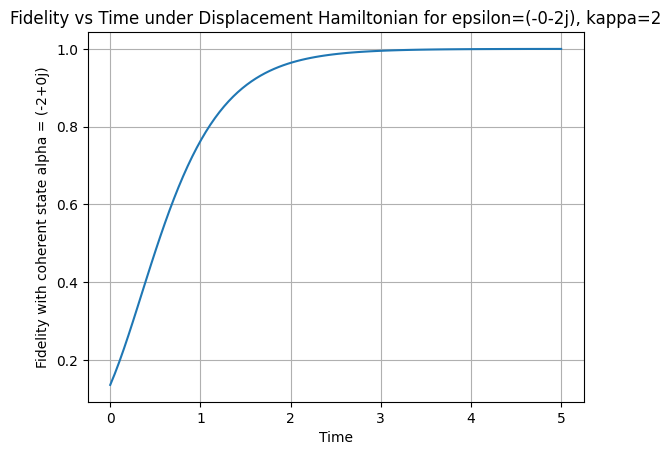

In [2]:
def disp_hamiltonian(epsilon, N):
    #displacement Hamiltonian as seen in the notes. 
    a = qt.destroy(N)
    adag = qt.create(N)
    H = epsilon.conjugate()*a+epsilon*adag
    return H

def disp_master_solve(epsilon, kappa, N, tlist):
    #solve the master equation for displacement hamiltonian with dissipation 
    H = disp_hamiltonian(epsilon, N)
    a = qt.destroy(N)
    #dissipation term
    L_ops = [np.sqrt(kappa)*a]
    #initialize term to vacuum, since numerically we truncate the QHO we need N high enough to capture the dynamics
    psi0 = qt.fock(N, 0)
    result = qt.mesolve(H, psi0, tlist, L_ops, [])
    return result

def plot_fidelity(epsilon, kappa, N, tlist, compare):
    #plot the fidelity between the time-evolved state and the target state (in our case we're comparing to a coherent state with alpha = 2)
    result = disp_master_solve(epsilon, kappa, N, tlist)
    #list comprehension to compute the fidelities at each time step
    fidelities = [qt.fidelity(compare, psi) for psi in result.states]

    #plot our stuff and shit
    plt.plot(tlist, fidelities)
    plt.xlabel('Time')
    plt.ylabel('Fidelity with coherent state alpha = '+str(-2j*epsilon/kappa))
    plt.title(f'Fidelity vs Time under Displacement Hamiltonian for epsilon={epsilon}, kappa={kappa}')
    plt.grid()
    plt.show()

#initialize parameters for our simulation
epsilon = -2j
kappa = 2
N = 100
alpha = -2j*epsilon/kappa
compare = qt.coherent(N, alpha)
tlist = np.linspace(0, 5, 100)

plot_fidelity(epsilon, kappa, N, tlist, compare)

# Bloch equation simulation



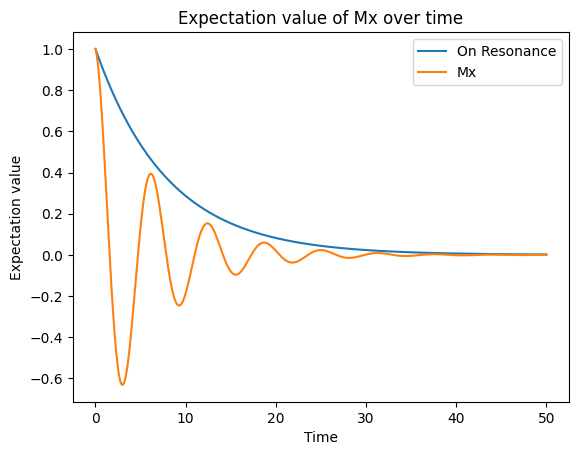

In [6]:
def plot_bloch_x(gamma, gamma1, gamma_phi, init_state, tf = 50, Bdir = [0,0,1]):
    # Define the Pauli matrices
    
    # Define the Hamiltonian for the qubit in the presence of a magnetic field
    rho = init_state*init_state.dag()
    H = gamma * 0.5*(Bdir[0] * qt.sigmax() + Bdir[1] * qt.sigmay() + Bdir[2] * qt.sigmaz())
    results = qt.mesolve(H, rho, np.linspace(0, tf, 1000), [np.sqrt(gamma1) * qt.destroy(2), np.sqrt(gamma_phi)*qt.sigmaz()])
    plt.plot(results.times, qt.expect(qt.sigmax(), results.states), label='Mx')

def textbook(mi, t, T2star):
    return mi*np.exp(-t/T2star) 

plus = 1/np.sqrt(2) * (qt.basis(2, 0) + qt.basis(2, 1))
T2star = 1/(0.1 + 0.05/2)
ytext = textbook(1, np.linspace(0, 50, 1000), T2star)
plt.plot(np.linspace(0, 50, 1000), ytext, label='On Resonance')
plot_bloch_x(1, 0.1, 0.05, plus) 
plt.xlabel('Time')
plt.ylabel('Expectation value')
plt.title('Expectation value of Mx over time')
plt.legend()
plt.show()

Simulating the master equation for a cat state with a single 2 photon jump operator. Additionally plotting the wigner function for the resulting at the end of the simulation.

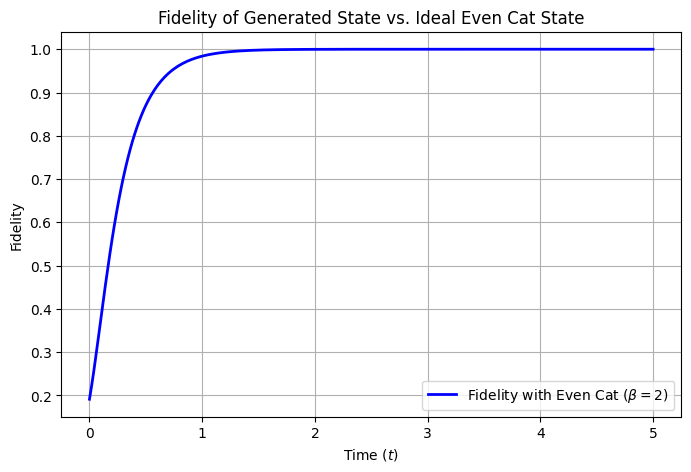

Steady state purity: 1.0000


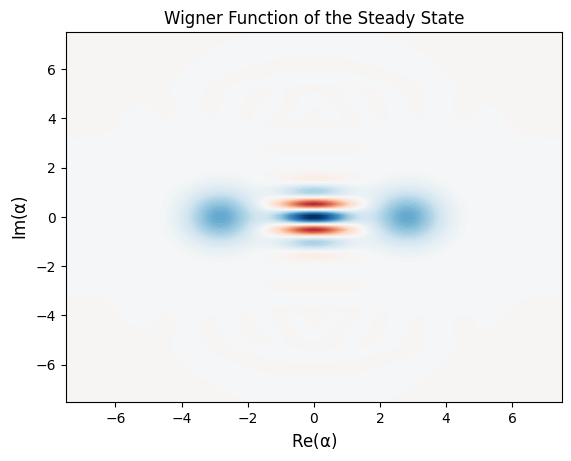

In [10]:
#7b

N = 25  # Hilbert space truncation
gamma_2 = 1.0
epsilon_2 = 2.0j
beta = 2.0


a = destroy(N)

# Hamiltonian
H = np.conj(epsilon_2) * a**2 + epsilon_2 * a.dag()**2

# loss term
c_ops = [np.sqrt(gamma_2) * a**2]

#initial state: vacuum |0>
psi0 = basis(N, 0)

#cat state beta=2
cat_ideal = (coherent(N, beta) + coherent(N, -beta)).unit()

#time list for simulation
tlist = np.linspace(0, 5/gamma_2, 250) 

#master equation simulation
result = mesolve(H, psi0, tlist, c_ops, [])


# Calculate the fidelity between the state at each time step and the ideal cat state
fidelities = [fidelity(rho, cat_ideal) for rho in result.states]

plt.figure(figsize=(8, 5))
plt.plot(tlist, fidelities, label=r'Fidelity with Even Cat ($\beta=2$)', color='blue', lw=2)
plt.xlabel(r'Time ($t$)')
plt.ylabel('Fidelity')
plt.title('Fidelity of Generated State vs. Ideal Even Cat State')
plt.grid(True)
plt.legend()
plt.show()


rho_steady = result.states[-1]

# Calculate and print purity
purity = rho_steady.purity()
print(f"Steady state purity: {purity:.4f}")

# Plot the Wigner function of the steady state
plot_wigner(rho_steady)
plt.title('Wigner Function of the Steady State')
plt.show()

Now adding a term to the wigner function to simulate single photon loss from the cavity. 

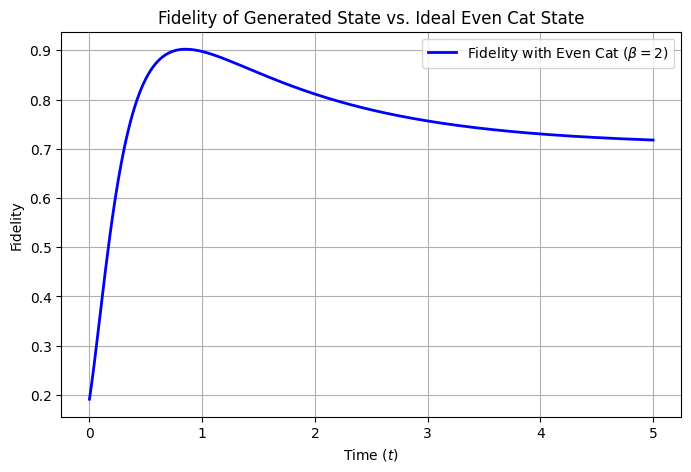

Steady state purity: 0.5004


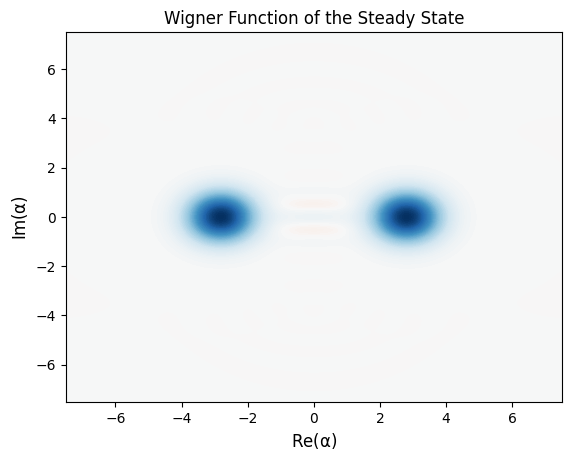

In [11]:
#7c
N = 25  # Hilbert space truncation
gamma_2 = 1.0
epsilon_2 = 2.0j
beta = 2.0
gamma_1 = gamma_2 / 10.0

# Add the new single-photon loss jump operator
c_ops = [
    np.sqrt(gamma_2) * a**2,  # Two-photon loss (from part b)
    np.sqrt(gamma_1) * a      # Single-photon loss (new for part c)
]


#initial state: vacuum |0>
psi0 = basis(N, 0)

#cat state beta=2
cat_ideal = (coherent(N, beta) + coherent(N, -beta)).unit()

#time list for simulation
tlist = np.linspace(0, 5/gamma_2, 250) 

#master equation simulation
result = mesolve(H, psi0, tlist, c_ops, [])


# Calculate the fidelity between the state at each time step and the ideal cat state
fidelities = [fidelity(rho, cat_ideal) for rho in result.states]

plt.figure(figsize=(8, 5))
plt.plot(tlist, fidelities, label=r'Fidelity with Even Cat ($\beta=2$)', color='blue', lw=2)
plt.xlabel(r'Time ($t$)')
plt.ylabel('Fidelity')
plt.title('Fidelity of Generated State vs. Ideal Even Cat State')
plt.grid(True)
plt.legend()
plt.show()


rho_steady = result.states[-1]

# Calculate and print purity
purity = rho_steady.purity()
print(f"Steady state purity: {purity:.4f}")

# Plot the Wigner function of the steady state
plot_wigner(rho_steady)
plt.title('Wigner Function of the Steady State')
plt.show()